In [11]:
import pandas as pd

df = pd.read_csv("spam.csv", encoding="latin-1")[["v1", "v2"]]
df.columns = ["label", "message"]
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})
df = df.drop_duplicates()

print(df.shape)
print(df["label"].value_counts())
df.head()

(5169, 3)
label
ham     4516
spam     653
Name: count, dtype: int64


,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


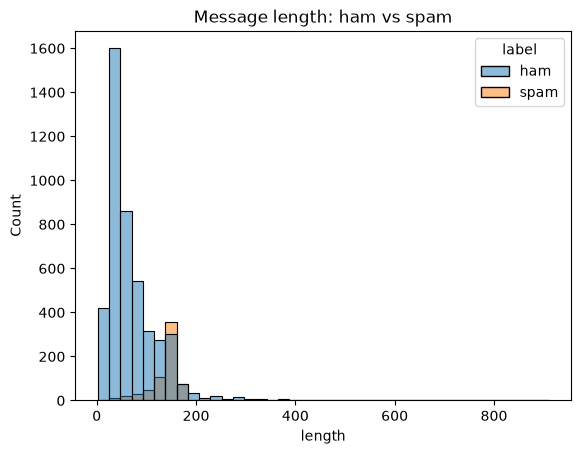

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

df["length"] = df["message"].str.len()

sns.histplot(data=df, x="length", hue="label", bins=40)
plt.title("Message length: ham vs spam")
plt.savefig("images/length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["message"], df["label_num"],
    test_size=0.2, random_state=42, stratify=df["label_num"]
)
print(len(X_train), len(X_test))

4135 1034


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

model = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, stop_words="english", ngram_range=(1, 2))),
    ("svm", LinearSVC(class_weight="balanced", random_state=42)),
])
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' a

Accuracy: 0.9825918762088974
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       903
        spam       0.97      0.89      0.93       131

    accuracy                           0.98      1034
   macro avg       0.98      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



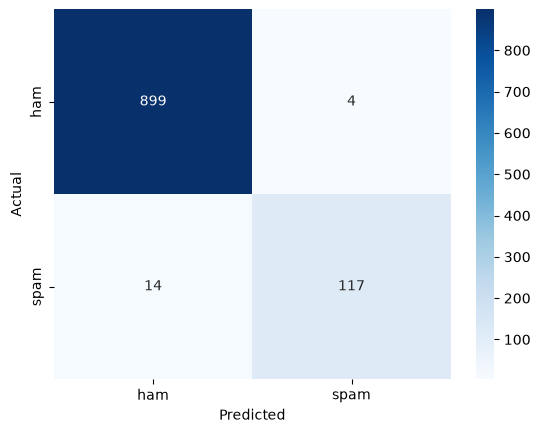

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("images/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
samples = [
    "Congratulations! You've won a FREE iPhone. Click here to claim now!",
    "Hey, are we still meeting for lunch at 1?",
    "URGENT: your account is suspended. Call 0800-123-456 immediately",
    "Can you send me the notes from today's class?",
]
for s, p in zip(samples, model.predict(samples)):
    print("SPAM" if p == 1 else "HAM", "->", s)

SPAM -> Congratulations! You've won a FREE iPhone. Click here to claim now!
HAM -> Hey, are we still meeting for lunch at 1?
SPAM -> URGENT: your account is suspended. Call 0800-123-456 immediately
HAM -> Can you send me the notes from today's class?


In [17]:
import joblib
joblib.dump(model, "spam_model.joblib")

['spam_model.joblib']

In [18]:
import numpy as np

names = model["tfidf"].get_feature_names_out()
coefs = model["svm"].coef_[0]
print("Top spam words:", list(names[np.argsort(coefs)[-15:]]))

Top spam words: ['146tf150p', 'stop', '50', 'prize', 'service', '150p', 'text', 'com', '½1', 'reply', 'www', 'claim', 'txt', 'mobile', 'uk']


In [19]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

total = len(df)
n_ham = int((df["label_num"] == 0).sum())
n_spam = int((df["label_num"] == 1).sum())

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

names = model["tfidf"].get_feature_names_out()
coefs = model["svm"].coef_[0]
top_words = ", ".join(names[np.argsort(coefs)[-15:]][::-1])

avg_spam = df[df.label_num == 1]["length"].mean()
avg_ham = df[df.label_num == 0]["length"].mean()
longer = "longer" if avg_spam > avg_ham else "shorter"

samples = [
    "Congratulations! You've won a FREE iPhone. Click here to claim now!",
    "Hey, are we still meeting for lunch at 1?",
    "URGENT: your account is suspended. Call 0800-123-456 immediately",
    "Can you send me the notes from today's class?",
]
preds = model.predict(samples)
sample_rows = "\n".join(
    f"| {s} | {'SPAM' if p == 1 else 'HAM'} |" for s, p in zip(samples, preds)
)

readme = f"""# Task 9: Spam Detector (TF-IDF + SVM)

## Overview
This project classifies SMS messages as **spam** or **ham** (not spam). Text is converted to numerical features with a TF-IDF vectorizer, and a Linear Support Vector Machine (SVM) separates the two classes.

## Dataset
- **Source:** SMS Spam Collection Dataset (UCI / Kaggle)
- **Size:** {total} messages after removing duplicates
- **Classes:** {n_ham} ham ({n_ham/total:.1%}) and {n_spam} spam ({n_spam/total:.1%})
- The data is **imbalanced**, so accuracy alone is not enough. Precision, recall and F1 for the spam class are reported too.

![Message length distribution](images/length_distribution.png)

Spam messages are {longer} than normal messages on average ({avg_spam:.0f} vs {avg_ham:.0f} characters).

## Approach
1. **Cleaning:** kept the label and message columns, mapped ham to 0 and spam to 1, removed duplicates.
2. **Split:** stratified 80/20 train/test split (`random_state=42`), giving {len(X_train)} training and {len(X_test)} test messages.
3. **Features:** `TfidfVectorizer` with lowercase, English stop words and unigrams + bigrams.
4. **Model:** `LinearSVC` with `class_weight="balanced"` to handle the imbalance.
5. **Pipeline:** vectorizer and classifier are wrapped in one scikit-learn `Pipeline`, so the vectorizer is fit only on training data (no data leakage).
6. **Saved model:** `spam_model.joblib`.

## How to Run
```bash
pip install -r requirements.txt
jupyter notebook spam_detector.ipynb
```
Or open `spam_detector.ipynb` in VS Code and choose **Run All**. Make sure `spam.csv` is in the same folder as the notebook.

## Results
Evaluated on the held-out test set ({len(X_test)} messages):

| Metric | Value |
|---|---|
| Accuracy | {acc:.2%} |
| Spam precision | {prec:.3f} |
| Spam recall | {rec:.3f} |
| Spam F1-score | {f1:.3f} |

![Confusion matrix](images/confusion_matrix.png)

**Interpretation:**
- Out of {tp + fn} real spam messages, the model caught {tp} and missed {fn}.
- It wrongly flagged {fp} normal messages as spam. This is the more costly mistake, since a real message could be lost.
- Overall the model separates the two classes well, and the spam-specific metrics confirm it is not just exploiting the class imbalance.

## Top Spam Indicators
Words with the highest spam weights in the model: {top_words}.

## Sample Predictions
| Message | Prediction |
|---|---|
{sample_rows}

## Project Structure
task_09_spam_detector/
├── spam_detector.ipynb # full workflow with outputs
├── spam.csv # dataset
├── spam_model.joblib # trained pipeline
├── requirements.txt
├── images/ # plots used in this README
└── README.md


## Challenges and Future Improvements
- **Class imbalance** was handled with class weights, but oversampling could also be tried.
- The model does not understand obfuscated words (for example "fr33" or "w1n").
- It is trained on English SMS only, so it may not generalize to emails.
- Next steps: hyperparameter tuning with `GridSearchCV`, a Naive Bayes baseline for comparison, and a transformer-based model.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme)

print(readme)

# Task 9: Spam Detector (TF-IDF + SVM)

## Overview
This project classifies SMS messages as **spam** or **ham** (not spam). Text is converted to numerical features with a TF-IDF vectorizer, and a Linear Support Vector Machine (SVM) separates the two classes.

## Dataset
- **Source:** SMS Spam Collection Dataset (UCI / Kaggle)
- **Size:** 5169 messages after removing duplicates
- **Classes:** 4516 ham (87.4%) and 653 spam (12.6%)
- The data is **imbalanced**, so accuracy alone is not enough. Precision, recall and F1 for the spam class are reported too.

![Message length distribution](images/length_distribution.png)

Spam messages are longer than normal messages on average (138 vs 71 characters).

## Approach
1. **Cleaning:** kept the label and message columns, mapped ham to 0 and spam to 1, removed duplicates.
2. **Split:** stratified 80/20 train/test split (`random_state=42`), giving 4135 training and 1034 test messages.
3. **Features:** `TfidfVectorizer` with lowercase, English stop w